<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/1.0.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_DIFF"] = df["SMA_5"] - df["SMA_25"]
df["SMA_RATIO"] = df["SMA_5"] / (df["SMA_25"] + 1e-9)

# --- Target ---
future_max = df["Close"].shift(-1).rolling(3).max()
df["Target"] = ((future_max / df["Close"] - 1) > 0.0075).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================

# モメンタム
df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# モメンタム補助
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================

df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

df["RANGE_SCORE"] = abs(df["RSI"] - 50)
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX
# ======================
df["ADX_normalized"] = df["ADX"] / 100  # ADXを0-1に正規化
# 初期データ準備ではデフォルトのADX閾値を使用 (Optunaで最適化)
default_adx_regime_threshold = 20
df["trend_regime"] = (df["ADX"] > default_adx_regime_threshold).astype(int)

# ======================
# cleanup
# ======================
df.dropna(inplace=True)

print("完了:", df.shape)


/tmp/ipykernel_142499/2547753321.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

完了: (1535, 36)


In [2]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'ADX',
    'ADX_normalized',  # ←追加: 正規化ADX
    'trend_regime',    # ←追加: トレンドレジーム
    'RET_5',           # ←スコアに使用するモメンタム
    'Volatility_Short' # ←スコアに使用するボラティリティ
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])


使用特徴量数: 23
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [3]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Xとy
X = df[features].copy()
y = df['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1535, 23)
y shape: (1535,)
Target分布:
Target
0    0.518567
1    0.481433
Name: proportion, dtype: float64


In [4]:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1535, 23)


In [5]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-03-17 00:00:00 → 2025-02-03 00:00:00
Test期間 : 2025-02-04 00:00:00 → 2026-04-24 00:00:00
Train size: (1228, 23)
Test size : (307, 23)


In [6]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
1    618
0    610
Name: count, dtype: int64
After SMOTE:
Target
0    618
1    618
Name: count, dtype: int64


In [7]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 313}


In [11]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
# pandas DataFrame/SeriesをNumPy配列に変換して渡すことでAttributeErrorを回避
random_search_xgb.fit(X_train_resampled.values, y_train_resampled.values)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.8650089137415928), 'gamma': np.float64(0.15585553804470548), 'learning_rate': np.float64(0.11401360423556216), 'max_depth': 6, 'n_estimators': 409, 'reg_alpha': np.float64(0.01565664622777929), 'reg_lambda': np.float64(1.7634271618924977), 'subsample': np.float64(0.7799016533479063)}


In [15]:
# ======================
# 予測確率の取得
# ======================

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
# pandas DataFrameをNumPy配列に変換して渡すことでAttributeErrorを回避
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test.values)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (307,)
XGB proba shape: (307,)


In [16]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 32
Strategy B trades: 99


In [17]:
# ======================
# バックテスト関数（完全版）
# ======================

import numpy as np
import pandas as pd

def run_backtest(
    df,
    X_test,
    signals,
    initial_balance=100000
):

    # --- テスト期間 ---
    df_bt = df.loc[X_test.index].copy()

    # 必須データチェック
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signals align
    signals = signals.loc[df_bt.index]

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []

    position = 0
    entry_price = 0
    entry_atr = 0  # ★重要：ATR固定

    trade_count = 0
    win_count = 0

    # --- 固定リスク管理パラメータ ---
    risk_per_trade = 0.01 # 1%リスク
    atr_tp_multiplier = 2.5 # TPは2.5 * ATR
    atr_sl_multiplier = 1.2 # SLは1.2 * ATR

    # ======================
    # メインループ
    # ======================
    for i in range(len(df_bt) - 1):

        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        signal = signals.iloc[i]

        # ======================
        # エントリー
        # ======================
        if position == 0 and signal > 0:

            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                equity_curve.append(balance)
                continue

            risk_amount = balance * risk_per_trade
            stop_distance = atr * atr_sl_multiplier

            position_size = risk_amount / stop_distance

            entry_price = next_row['Close']
            entry_atr = atr  # ★固定

            position = position_size
            trade_count += 1

        # ======================
        # ポジション管理
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            stop_price = entry_price - (entry_atr * atr_sl_multiplier)
            take_profit_price = entry_price + (entry_atr * atr_tp_multiplier)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:

                pnl = (current_price - entry_price) * position
                balance += pnl

                if pnl > 0:
                    win_count += 1

                position = 0

        # ======================
        # equity（ここが超重要）
        # ======================
        if position > 0:
            unrealized = (row['Close'] - entry_price) * position
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # ======================
    # 強制決済
    # ======================
    if position > 0:

        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl

        if pnl > 0:
            win_count += 1

        equity_curve[-1] = balance

    # ======================
    # 指標
    # ======================
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)

    # ドローダウン
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # シャープ（簡易）
    returns = np.diff(equity) / equity[:-1]
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    # プロフィットファクター
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    expectancy = np.mean(returns)

    results = {
        "Final Balance": balance,
        "Total Return (%)": total_return,
        "Total Trades": trade_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe
    }

    return results, equity_curve

In [18]:
# ======================
# バックテスト実行
# ======================

import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# --- 戦略A ---
results_A, equity_A = run_backtest(df, X_test, signals_A)

# --- 戦略B ---
results_B, equity_B = run_backtest(df, X_test, signals_B)

# 結果表示
print("===== Strategy A =====")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B =====")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A =====
Final Balance: 104721.58921501615
Total Return (%): 4.721589215016153
Total Trades: 9
Win Rate (%): 44.44444444444444
PF: 1.1385994559585786
Expectancy: 0.00016185418456769003
Max DD: -0.07708569040675756
Sharpe: 0.5294163067204143

===== Strategy B =====
Final Balance: 99038.79022281652
Total Return (%): -0.9612097771834804
Total Trades: 12
Win Rate (%): 33.33333333333333
PF: 0.9885989119772783
Expectancy: -1.7372171515775404e-05
Max DD: -0.08646757213940073
Sharpe: -0.049549107349921157


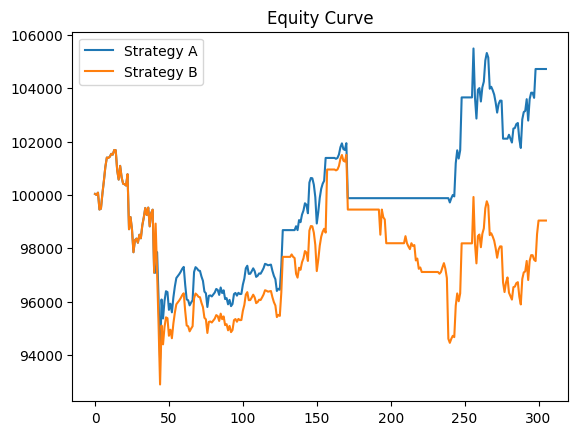

In [19]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [22]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0 # PF, MaxDD, Expectancy, Stability, Sharpe

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    expectancy = returns.mean()
    vol = returns.std() + 1e-9
    stability = 1 / vol
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    return pf, max_dd, expectancy, stability, sharpe


# ======================
# Optuna Objective (Refactored)
# ======================
def objective(trial):

    # ===== model params =====
    model_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),
    }

    # ===== Entry Ranking Model Weights and Top-K Selection =====
    # Entry Score = model_proba + w_trend_strength * TREND_STRENGTH.abs() - w_volatility_penalty * Volatility_Short + w_momentum * RET_5
    w_trend_strength = trial.suggest_float("w_trend_strength", 0.0, 5.0) # Weight for TREND_STRENGTH.abs()
    w_volatility_penalty = trial.suggest_float("w_volatility_penalty", 0.0, 5.0) # Weight for Volatility_Short (penalty)
    w_momentum = trial.suggest_float("w_momentum", 0.0, 5.0) # Weight for RET_5 (momentum)
    num_top_trades_per_fold = trial.suggest_int("num_top_trades_per_fold", 5, 15) # K for Top-K selection per fold

    # ===== Objective Weights =====
    # Sharpe最大化を目的関数に明確に設定, PFよりExpectancy優先
    w_pf = trial.suggest_float("w_pf", 0.0, 0.3)  # Lower priority for PF
    w_exp = trial.suggest_float("w_exp", 0.4, 0.7) # Higher priority for Expectancy
    w_sharpe = trial.suggest_float("w_sharpe", 0.1, 0.4) # Explicitly for Sharpe

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    trade_counts_per_fold = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        df_val = df.loc[X_val.index].copy()

        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        model = XGBClassifier(**model_params, random_state=42, eval_metric="logloss")
        model.fit(X_train_res.values, y_train_res.values)

        proba = model.predict_proba(X_val.values)[:, 1]
        df_val["proba"] = proba

        # Ensure all required features for Entry Ranking Model are in df_val
        df_val['ADX'] = df.loc[X_val.index, 'ADX']
        df_val['Volatility_Short'] = df.loc[X_val.index, 'Volatility_Short']
        df_val['TREND_STRENGTH'] = df.loc[X_val.index, 'TREND_STRENGTH']
        df_val['RET_5'] = df.loc[X_val.index, 'RET_5']

        # ===== Entry Ranking Model Logic =====
        # Calculate Entry Score
        df_val["entry_score"] = (
            df_val["proba"]
            + w_trend_strength * df_val["TREND_STRENGTH"].abs()
            - w_volatility_penalty * df_val["Volatility_Short"]
            + w_momentum * df_val["RET_5"]
        )

        # Top-K selection: Select num_top_trades_per_fold signals with the highest entry_score
        signals = pd.Series(0.0, index=df_val.index)
        if len(df_val) > 0: # Avoid error if df_val is empty
            top_k_indices = df_val.nlargest(num_top_trades_per_fold, "entry_score").index
            signals.loc[top_k_indices] = 1.0

        signals_series = signals

        # ===== Backtest =====
        results, equity = run_backtest(df, X_val, signals_series)

        pf, max_dd, exp, stability, sharpe = calc_metrics(equity)

        # DD制約（ガードレール）
        if max_dd > 0.08:
            score = -1e6
            scores.append(score)
        else:
            # 正規化 (tanhを使用)
            pf_norm = np.tanh(np.clip(pf - 1, -1, 4))
            exp_norm = np.tanh(exp * 5000) # Assuming expectancy is small, scale it up
            sharpe_norm = np.tanh(np.clip(sharpe / 1.5, 0, 2)) # Scale Sharpe to a reasonable range

            total_w = w_pf + w_exp + w_sharpe + 1e-9

            # Objective function combines the weighted normalized metrics
            current_score = (w_pf / total_w) * pf_norm + \
                            (w_exp / total_w) * exp_norm + \
                            (w_sharpe / total_w) * sharpe_norm

            # Trade数制御: 5〜15の範囲外でペナルティ (soft penalty per fold)
            total_trades = results["Total Trades"]
            trade_counts_per_fold.append(total_trades)

            if total_trades < 5:
                current_score -= 0.2 * (5 - total_trades) / 5
            elif total_trades > 15:
                current_score -= 0.1 * (total_trades - 15) / 15

            scores.append(current_score)

    # Final score is the mean of scores across folds
    # Additional penalty for average trade count across all folds
    avg_trades_across_folds = np.mean(trade_counts_per_fold) if trade_counts_per_fold else 0
    mean_scores = np.mean(scores)

    if avg_trades_across_folds < 5:
        mean_scores -= 0.5 * (5 - avg_trades_across_folds) / 5
    elif avg_trades_across_folds > 15:
        mean_scores -= 0.2 * (avg_trades_across_folds - 15) / 15

    return mean_scores


# ======================
# 実行
# ======================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) # Increased n_trials for better optimization

print(study.best_params)


# ======================
# 後処理（完全安全版）
# ======================
best = study.best_params

model_params = {k: best[k] for k in [
    "n_estimators","max_depth","learning_rate",
    "subsample","colsample_bytree",
    "gamma","reg_alpha","reg_lambda"
]}

# 新しい戦略パラメータを個別に抽出

# Entry Ranking Model Weights and Top-K selection
w_trend_strength = best.get("w_trend_strength")
w_volatility_penalty = best.get("w_volatility_penalty")
w_momentum = best.get("w_momentum")
num_top_trades_per_fold = best.get("num_top_trades_per_fold")

# Objective Weights (for info only, not used in signal generation)
w_pf = best.get("w_pf")
w_exp = best.get("w_exp")
w_sharpe = best.get("w_sharpe")

print("MODEL:", model_params)
print("Entry Ranking Model Weights: Trend Strength=", w_trend_strength, ", Volatility Penalty=", w_volatility_penalty, ", Momentum=", w_momentum)
print("Num Top Trades per Fold:", num_top_trades_per_fold)
print("Objective Weights: PF=", w_pf, ", Exp=", w_exp, ", Sharpe=", w_sharpe)


[I 2026-04-25 13:50:21,864] A new study created in memory with name: no-name-32ec338d-4475-45b6-9ee1-d57e4167b93e
[I 2026-04-25 13:50:31,832] Trial 0 finished with value: -0.11685789513986082 and parameters: {'n_estimators': 279, 'max_depth': 5, 'learning_rate': 0.16510636932439435, 'subsample': 0.7944325938172561, 'colsample_bytree': 0.8546683426597355, 'gamma': 0.19765982935916349, 'reg_alpha': 0.17176041370141, 'reg_lambda': 0.8727668291978934, 'w_trend_strength': 4.953930355876805, 'w_volatility_penalty': 1.336639939403343, 'w_momentum': 4.8977323878792705, 'num_top_trades_per_fold': 10, 'w_pf': 0.13641085916867232, 'w_exp': 0.41288950885412945, 'w_sharpe': 0.33631438478953446}. Best is trial 0 with value: -0.11685789513986082.
[I 2026-04-25 13:50:34,166] Trial 1 finished with value: -0.2610805020319454 and parameters: {'n_estimators': 137, 'max_depth': 10, 'learning_rate': 0.06890909092231967, 'subsample': 0.7257811013861628, 'colsample_bytree': 0.9995777335873465, 'gamma': 0.4868

{'n_estimators': 165, 'max_depth': 10, 'learning_rate': 0.11316461283369074, 'subsample': 0.9461081092786296, 'colsample_bytree': 0.8598557806051685, 'gamma': 0.23946554524285607, 'reg_alpha': 0.2072786180948296, 'reg_lambda': 0.5533442161289107, 'w_trend_strength': 1.684483258885053, 'w_volatility_penalty': 2.9426623870707473, 'w_momentum': 4.178148687537574, 'num_top_trades_per_fold': 12, 'w_pf': 0.00018827560099477642, 'w_exp': 0.4015593648937218, 'w_sharpe': 0.379052025456534}
MODEL: {'n_estimators': 165, 'max_depth': 10, 'learning_rate': 0.11316461283369074, 'subsample': 0.9461081092786296, 'colsample_bytree': 0.8598557806051685, 'gamma': 0.23946554524285607, 'reg_alpha': 0.2072786180948296, 'reg_lambda': 0.5533442161289107}
Entry Ranking Model Weights: Trend Strength= 1.684483258885053 , Volatility Penalty= 2.9426623870707473 , Momentum= 4.178148687537574
Num Top Trades per Fold: 12
Objective Weights: PF= 0.00018827560099477642 , Exp= 0.4015593648937218 , Sharpe= 0.37905202545653

In [23]:
print("proba exists:", "proba" in globals())

proba exists: False


In [24]:
model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [29]:
# ======================
# 最終モデル + 最終バックテスト（完成版）
# ======================

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ======================
# パラメータ取得（-lj2XmmykqNY で抽出済みのものを使用）
# ======================

# model_params は -lj2XmmykqNY で定義済み
# 新しい戦略パラメータを best から取得

w_trend_strength = best.get("w_trend_strength")
w_volatility_penalty = best.get("w_volatility_penalty")
w_momentum = best.get("w_momentum")
num_top_trades_per_fold = best.get("num_top_trades_per_fold")

print("Final Model Params:", model_params)
print("Final Entry Ranking Model Weights: Trend Strength=", w_trend_strength, ", Volatility Penalty=", w_volatility_penalty, ", Momentum=", w_momentum)
print("Final Num Top Trades:", num_top_trades_per_fold)


# ======================
# 再学習
# ======================

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

final_model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

final_model.fit(X_train_resampled.values, y_train_resampled.values)

# ======================
# 予測
# ======================

proba_final = final_model.predict_proba(X_test.values)[:, 1]

# ======================
# 戦略生成（Entry Ranking Model with Top-K selection）
# ======================

df_test_slice = df.loc[X_test.index].copy()
df_test_slice["proba"] = proba_final

# Ensure all required features for Entry Ranking Model are in df_test_slice
df_test_slice['ADX'] = df.loc[X_test.index, 'ADX']
df_test_slice['Volatility_Short'] = df.loc[X_test.index, 'Volatility_Short']
df_test_slice['TREND_STRENGTH'] = df.loc[X_test.index, 'TREND_STRENGTH']
df_test_slice['RET_5'] = df.loc[X_test.index, 'RET_5']

# Calculate Entry Score based on optimized weights
df_test_slice["entry_score"] = (
    df_test_slice["proba"]
    + w_trend_strength * df_test_slice["TREND_STRENGTH"].abs()
    - w_volatility_penalty * df_test_slice["Volatility_Short"]
    + w_momentum * df_test_slice["RET_5"]
)

# Top-K selection: Select num_top_trades_per_fold signals with the highest entry_score
signals_final = pd.Series(0.0, index=df_test_slice.index)
if len(df_test_slice) > 0: # Avoid error if df_test_slice is empty
    top_k_indices = df_test_slice.nlargest(int(num_top_trades_per_fold), "entry_score").index
    signals_final.loc[top_k_indices] = 1.0

signals_final = pd.Series(signals_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final = run_backtest(
    df,
    X_test,
    signals_final
)

# ======================
# 結果
# ======================

print("===== FINAL RESULT ====")
for k, v in results_final.items():
    print(f"{k}: {v}")


Final Model Params: {'n_estimators': 165, 'max_depth': 10, 'learning_rate': 0.11316461283369074, 'subsample': 0.9461081092786296, 'colsample_bytree': 0.8598557806051685, 'gamma': 0.23946554524285607, 'reg_alpha': 0.2072786180948296, 'reg_lambda': 0.5533442161289107}
Final Entry Ranking Model Weights: Trend Strength= 1.684483258885053 , Volatility Penalty= 2.9426623870707473 , Momentum= 4.178148687537574
Final Num Top Trades: 12
===== FINAL RESULT ====
Final Balance: 104402.06454536284
Total Return (%): 4.402064545362849
Total Trades: 5
Win Rate (%): 60.0
PF: 1.3348588633514944
Expectancy: 0.00014572453398952387
Max DD: -0.022285138568584224
Sharpe: 0.7721732324102667


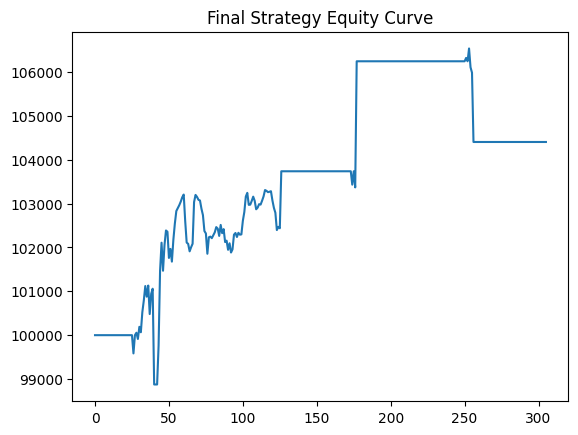

In [30]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

In [34]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

best_params_cv = study.best_params.copy()


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # model params
    # XGBoostモデルに渡すパラメータのみを抽出
    model_params_for_xgb = {
        k: best_params_cv[k]
        for k in best_params_cv
        if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
    }

    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res.values, y_train_res.values)

    # prediction
    proba = model.predict_proba(X_test_cv.values)[:, 1]

    # align df
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice["proba"] = proba

    # Extract strategy parameters from best_params_cv
    # Regime Filter Params
    # These parameters are not present in `best_params_cv` from the current Optuna setup.
    # They were part of a previous strategy design.
    # We need to ensure that the strategy applied here aligns with the Optuna objective used.
    # As per the new strategy, we are using weights for Entry Ranking Model and Top-K selection.
    # So, remove these regime filter parameters from here.

    # Entry Model Params
    # entry_proba_threshold = best_params_cv.get("entry_proba_threshold") # Removed as per new strategy

    # Re-calculate required features for signal generation
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5'] # Add RET_5 for the new Entry Ranking Model

    # Retrieve Entry Ranking Model weights and num_top_trades from best_params_cv
    w_trend_strength_cv = best_params_cv.get("w_trend_strength")
    w_volatility_penalty_cv = best_params_cv.get("w_volatility_penalty")
    w_momentum_cv = best_params_cv.get("w_momentum")
    num_top_trades_per_fold_cv = best_params_cv.get("num_top_trades_per_fold")

    # Calculate Entry Score based on optimized weights
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * df_slice["TREND_STRENGTH"].abs()
        - w_volatility_penalty_cv * df_slice["Volatility_Short"]
        + w_momentum_cv * df_slice["RET_5"]
    )

    # Top-K selection: Select num_top_trades_per_fold signals with the highest entry_score
    signals = pd.Series(0.0, index=df_slice.index)
    if len(df_slice) > 0: # Avoid error if df_slice is empty
        top_k_indices = df_slice.nlargest(int(num_top_trades_per_fold_cv), "entry_score").index
        signals.loc[top_k_indices] = 1.0

    signals_series = signals

    # backtest
    results, equity = run_backtest(
        df,
        X_test_cv,
        signals_series
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())



===== Fold 1 ====
{'Final Balance': np.float64(106856.77207492606), 'Total Return (%)': np.float64(6.856772074926054), 'Total Trades': 5, 'Win Rate (%)': 80.0, 'PF': np.float64(2.647588961052186), 'Expectancy': np.float64(0.00026563810378382404), 'Max DD': np.float64(-0.016207678745872454), 'Sharpe': np.float64(1.5917444737689908), 'Sortino': np.float64(0.08144757605915173), 'Stability': np.float64(377.47023276139015)}

===== Fold 2 ====
{'Final Balance': np.float64(96395.69719116663), 'Total Return (%)': np.float64(-3.6043028088333706), 'Total Trades': 3, 'Win Rate (%)': 0.0, 'PF': np.float64(0.6360122609437274), 'Expectancy': np.float64(-0.00014205456583484384), 'Max DD': np.float64(-0.04212430892010095), 'Sharpe': np.float64(-0.9183936774333734), 'Sortino': np.float64(-0.028414857990308677), 'Stability': np.float64(407.2615574000413)}

===== Fold 3 ====
{'Final Balance': np.float64(100537.81090408302), 'Total Return (%)': np.float64(0.5378109040830248), 'Total Trades': 2, 'Win Rate

In [ ]:
print('ADX' in df.columns)
print(df.columns)